<a href="https://colab.research.google.com/github/wyogifirdaus-sudo/Sentiment-Kelompok-kiri/blob/main/scrapping_komunisme.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import urllib.parse
import requests
from bs4 import BeautifulSoup
def cari_berita_terkait(topik):
    print(f"\n🔍 Mencari berita terbaru terkait: '{topik}'...")

    # Encode the topic to make it safe for use in URL (example: "Timnas Indonesia" -> "Timnas+Indonesia")
    topik_encoded = urllib.parse.quote_plus(topik)
    url = f"https://news.google.com/rss/search?q={topik_encoded}&hl=id&gl=ID&ceus=ID:id"

    response = requests.get(url)
    soup = BeautifulSoup(response.text, 'xml')
    items = soup.find_all('item')

    news_data = [] # Initialize a list to store news data

    # Select the top 3 news stories related to that trend
    for index, item in enumerate(items[:200], 1):
        title = item.title.text
        link = item.link.text
        date = item.pubDate.text if item.pubDate else 'N/A' # Extract date, default to 'N/A' if not found
        kategori = item.category.text if item.category else 'N/A' # Extract category, default to 'N/A' if not found
        print(f"   [{index}] {title}")
        print(f"       Link: {link}")
        news_data.append({'Judul': title, 'Date': date, 'Kategori': kategori, 'Link': link}) # Store title and link

    return pd.DataFrame(news_data) # Return a DataFrame

# --- Cara Pakai ---
topik_tren_hari_ini = "komunisme"
df = cari_berita_terkait(topik_tren_hari_ini) # Assign the returned DataFrame to df


🔍 Mencari berita terbaru terkait: 'komunisme'...
   [1] Trump Pidato Hari Kemerdekaan AS: Komunisme Itu Pecundang - detikNews
       Link: https://news.google.com/rss/articles/CBMipgFBVV95cUxNc3hpdkxDSWFtQkstRGg4UGQwUklQTXlpb1gxb2dvazFNYTBxOGhXem0xTDNqUXFyMWpIRW9pYW1UZl9fOXJKUTNfMUtQQ1R3ZWs5WFpOeFI3M3dva1hFR2h5NzVXanAwbURQNW9PdEx0UVpqN0h4VVllSU1rWjM3ZDRiaFpHcVJwM1hYWFB6OVptS1l3MXBLTlVscEJlRXJvaGF6eXBB0gGrAUFVX3lxTE9MTmFOUnVJSXllVkRMb1NaZEZGQlZjckZSTGtVZnQ1VDNSQVU0VHJvcDRxM2RIQ1F2UzhjdkhocFIwQXEtY0tvWUdLb2xKNFYteTNrclEweXk5UTU1c3VvWjd5QklHblY5cDJCUFhGcDZicmpSSjRXTFVPdURwMzFIOGVBVTVsbzN3TGRuZ2JLYnFNMDBHQjI2TW5DUVVuVE5HZnBZU1ZGMHFkdw?oc=5
   [2] Kisah Partai Komunis di India – Mengapa pengaruhnya memudar? - BBC
       Link: https://news.google.com/rss/articles/CBMiYEFVX3lxTFBYcFJuWXlKbWZ0R3k2TTR4LVJaeWVmRDF6NzZkMkJxNmhESkozSmdBSTFzVTRaaEp3Q1FQd3J5QUM1bmZ4RzFvU1FoRm9nTnRNbEZwbVdQSU1WQ0NWTzdVZtIBZkFVX3lxTFBPUnBINC1tTVB4WFhtZC1yOTNlMWJrZjN3b2s3SWFlZWhxRU4zdHIwZHhsX1o0OXAxd3U2NFp1enNLbjRWa0R

In [ ]:
df.to_csv('beritakomunis.csv', index=False) # Saving scaping news into CSV

In [ ]:
# Opened document in CSV format
import pandas as pd
data_komunis = pd.read_csv("/content/beritakomunis.csv", on_bad_lines='warn')
data_komunis.head()

,Judul,Date,Kategori,Link
0,Trump Pidato Hari Kemerdekaan AS: Komunisme It...,"Sun, 05 Jul 2026 07:00:00 GMT",NaN,https://news.google.com/rss/articles/CBMipgFBV...
1,Kisah Partai Komunis di India – Mengapa pengar...,"Sat, 30 May 2026 07:00:00 GMT",NaN,https://news.google.com/rss/articles/CBMiYEFVX...
2,Komunisme Akademik: Pemaksaan Keseragaman di T...,"Fri, 31 Jul 2026 00:56:25 GMT",NaN,https://news.google.com/rss/articles/CBMiqAFBV...
3,Menkum Pastikan Kajian Ideologi Komunisme Tak ...,"Mon, 05 Jan 2026 08:00:00 GMT",NaN,https://news.google.com/rss/articles/CBMisgFBV...
4,Trump soroti Iran dan komunisme dalam pidato A...,"Sat, 04 Jul 2026 07:00:00 GMT",NaN,https://news.google.com/rss/articles/CBMinwFBV...


In [ ]:
data_komunis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Judul     100 non-null    object 
 1   Date      100 non-null    object 
 2   Kategori  0 non-null      float64
 3   Link      100 non-null    object 
dtypes: float64(1), object(3)
memory usage: 3.3+ KB


In [ ]:
data_komunis.duplicated().sum()

np.int64(0)

In [ ]:
data_komunis.drop_duplicates(inplace=True)
data_komunis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Judul     100 non-null    object 
 1   Date      100 non-null    object 
 2   Kategori  0 non-null      float64
 3   Link      100 non-null    object 
dtypes: float64(1), object(3)
memory usage: 3.3+ KB


In [ ]:
data_komunis.isnull().sum()

,0
Judul,0
Date,0
Kategori,100
Link,0


In [ ]:
data_komunis.drop("Kategori",axis=1,inplace=True)

In [ ]:
data_komunis.head()

,Judul,Date,Link
0,Trump Pidato Hari Kemerdekaan AS: Komunisme It...,"Sun, 05 Jul 2026 07:00:00 GMT",https://news.google.com/rss/articles/CBMipgFBV...
1,Kisah Partai Komunis di India – Mengapa pengar...,"Sat, 30 May 2026 07:00:00 GMT",https://news.google.com/rss/articles/CBMiYEFVX...
2,Komunisme Akademik: Pemaksaan Keseragaman di T...,"Fri, 31 Jul 2026 00:56:25 GMT",https://news.google.com/rss/articles/CBMiqAFBV...
3,Menkum Pastikan Kajian Ideologi Komunisme Tak ...,"Mon, 05 Jan 2026 08:00:00 GMT",https://news.google.com/rss/articles/CBMisgFBV...
4,Trump soroti Iran dan komunisme dalam pidato A...,"Sat, 04 Jul 2026 07:00:00 GMT",https://news.google.com/rss/articles/CBMinwFBV...


          Date  Jumlah Berita
0   2016-10-16              1
1   2016-12-15              1
2   2017-09-30              1
3   2017-12-06              1
4   2020-05-15              1
..         ...            ...
70  2026-07-05              5
71  2026-07-06              2
72  2026-07-09              1
73  2026-07-31              1
74  2026-08-30              1

[75 rows x 2 columns]


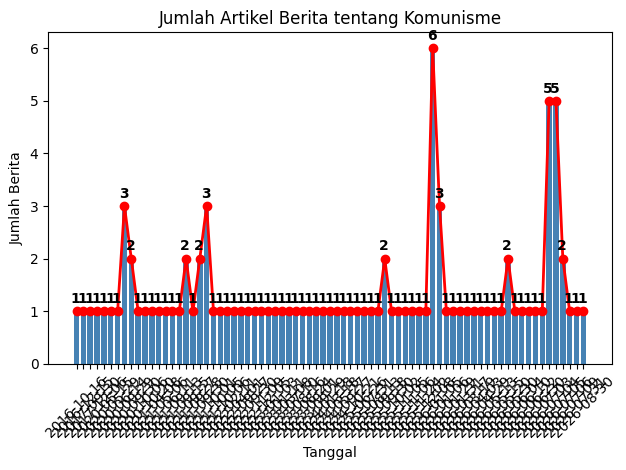

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert the "Date" column to the datetime format
data_komunis["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Count number of news stories as of the date
jumlah_berita = (
    df.groupby(data_komunis["Date"].dt.date)
      .size()
      .reset_index(name="Jumlah Berita")
)

# Sort by date
jumlah_berita = jumlah_berita.sort_values("Date")

# Display results
print(jumlah_berita)

bars = plt.bar(
    jumlah_berita["Date"].astype(str),
    jumlah_berita["Jumlah Berita"],
    color="steelblue"
)

# Increase in number of cases
for bar in bars:
    tinggi = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/3,
        tinggi + 0.1,              # posisi sedikit di atas batang
        f"{int(tinggi)}",          # menampilkan jumlah kasus
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Trend line
plt.plot(
    jumlah_berita["Date"].astype(str),
    jumlah_berita["Jumlah Berita"],
    marker="o",
    linewidth=2,
    color="red",
    label="Tren"
)

plt.title("Jumlah Artikel Berita tentang Komunisme")
plt.xlabel("Tanggal")
plt.ylabel("Jumlah Berita")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()